In [1]:
import numpy as np
import random
from scipy.stats import bernoulli
import matplotlib.pyplot as plt

# random choice of {0,1}

In [2]:
%timeit random.choice([0, 1])

720 ns ± 2.88 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [3]:
%timeit np.random.choice([0, 1])

27.1 µs ± 968 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


# random value generation for [0,1)

## single value

In [4]:
%timeit random.random()

89.2 ns ± 0.105 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [5]:
%timeit np.random.random()

565 ns ± 5.18 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


## multiple values

In [6]:
%timeit np.array([random.random() for i in range(100)])

20.2 µs ± 257 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [7]:
%timeit np.random.random(size=100)

2.85 µs ± 29.3 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## uniform distributino

In [8]:
x_random = np.random.random(size = 1000000)

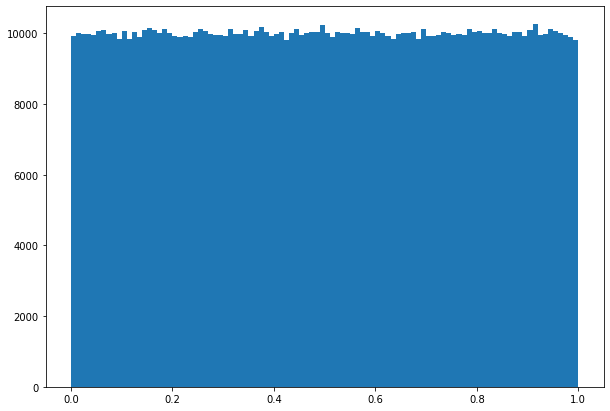

In [9]:
fig, ax = plt.subplots(figsize =(10, 7))
ax.hist(x_random, bins = 100)
# Show plot
plt.show()

# Bernoulli

In [10]:
def fetch_meth_state(read_meth):
    '''set methylation states based on the meth_arr'''
    meth_states = np.zeros(read_meth.size)
    nonzero_idx = np.where(read_meth)[0]    # this returns a tuple
    meth_states[nonzero_idx] = bernoulli.rvs(read_meth[nonzero_idx], size = nonzero_idx.size)
    return meth_states

def fetch_meth_state2(read_meth):
    return np.random.random(size = read_meth.size) < read_meth

In [11]:
read_meth   = np.zeros(150)
num_nonzero = 20
nonzero_idx = random.sample(range(150), num_nonzero)
read_meth[nonzero_idx] = [ random.random() for _ in range(num_nonzero)]

In [12]:
read_meth

array([0.        , 0.        , 0.2017991 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.1939403 , 0.        , 0.        , 0.85532316, 0.        ,
       0.        , 0.        , 0.        , 0.50119229, 0.        ,
       0.48595125, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.40388579, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.02551573, 0.64545476,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.30113407, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## time it

In [13]:
%timeit fetch_meth_state(read_meth)

193 µs ± 323 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [14]:
%timeit fetch_meth_state2(read_meth)

6.43 µs ± 29.1 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## validate

In [15]:
fetch_meth_state(read_meth)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
fetch_meth_state2(read_meth)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False,  True, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False,

In [17]:
list1 = []
list2 = []

for i in range(10000):
    list1.append(fetch_meth_state(read_meth).sum())
    list2.append(fetch_meth_state2(read_meth).sum())

In [18]:
# plot the histogram
np.fromstring('3,3,', dtype=float, sep=',')

array([3., 3.])

# discrete distribution

In [19]:
def np_discrete(x, p):
    '''x is the dicrete values corresponding to p'''
    return np.random.choice(x, p = p)

def np_discrete2(x, p_cum):
    '''x is a random value (1d array) in [0,1)'''
    # can precompute np.cumsum(p)
    return np.searchsorted(p_cum, x)[0]

In [20]:
x = [i for i in range(50)]
y = np.random.random(50)
z = y[0:1]
p = y/y.sum()

In [21]:
%timeit np.random.choice(x, p = p)

54.8 µs ± 592 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [22]:
%timeit np_discrete(x, p)

54.9 µs ± 296 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [23]:
%timeit np_discrete2(z,p)

3.94 µs ± 936 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## break down

In [24]:
%timeit np.array([1])

1.05 µs ± 3.81 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [25]:
%timeit x[0:1]

109 ns ± 0.202 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [26]:
%timeit np.array([random.random()])

1.05 µs ± 6.24 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [27]:
%timeit np.cumsum(p)

4.26 µs ± 35 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [28]:
p_cum = np.cumsum(p)
x = np.array([random.random()])

In [29]:
%timeit np.searchsorted(p_cum, x)[0]

3.42 µs ± 247 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


# qual_arr simulate

In [30]:
p_mat = np.array(np.random.random(2500)).reshape(50,50)
p_mat/=np.sum(p_mat, axis=1).reshape(-1,1)

In [31]:
p_mat

array([[0.023834  , 0.02117617, 0.00358083, ..., 0.03229517, 0.00960757,
        0.03735141],
       [0.03386042, 0.01873373, 0.03465017, ..., 0.02827868, 0.02257767,
        0.03361744],
       [0.0269256 , 0.03450547, 0.02102272, ..., 0.03272593, 0.02270647,
        0.01434644],
       ...,
       [0.02791894, 0.02786069, 0.03140863, ..., 0.01141777, 0.00224258,
        0.0160043 ],
       [0.01003165, 0.02041549, 0.03838654, ..., 0.0396391 , 0.03336457,
        0.02319021],
       [0.01787846, 0.03017938, 0.00937057, ..., 0.03554335, 0.01054642,
        0.01789227]])

In [32]:
p_mat_cum = np.cumsum(p_mat, axis=1)

In [33]:
p_mat_cum[49,:]

array([0.01787846, 0.04805783, 0.0574284 , 0.07967351, 0.09427109,
       0.10821408, 0.11987927, 0.15099321, 0.18629662, 0.19511852,
       0.20973889, 0.21395835, 0.25215975, 0.26080588, 0.29491199,
       0.31243559, 0.32992724, 0.36437864, 0.39191146, 0.42221352,
       0.45955376, 0.46040645, 0.47731716, 0.50139811, 0.5109116 ,
       0.52479973, 0.54464832, 0.58065161, 0.61532369, 0.62039632,
       0.64730168, 0.66724503, 0.683143  , 0.69058685, 0.69722221,
       0.71638594, 0.73030679, 0.7532922 , 0.75381794, 0.78184812,
       0.8126693 , 0.82209124, 0.85133299, 0.86573379, 0.89959187,
       0.92708051, 0.93601796, 0.97156131, 0.98210773, 1.        ])

In [34]:
def gen_qual(p_mat_cum, read_len=100):
    qual_arr = np.zeros(read_len)
    x_random = np.random.random(size = read_len)
    
    qual = 30
    for ix in range(read_len):
        qual = np_discrete2(x_random[ix:(ix+1)], p_mat_cum[qual,:])
        qual_arr[ix] = qual
    return qual_arr

In [35]:
%timeit gen_qual(p_mat_cum, read_len=100)

521 µs ± 3.17 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [36]:
gen_qual(p_mat_cum, read_len = 100)

array([11., 27.,  5., 20., 49., 15., 22.,  7.,  2., 16., 42., 32., 35.,
       14., 29., 49., 42., 38., 20.,  8., 37., 12.,  1., 10., 19., 23.,
       27., 29., 11., 27., 13., 31.,  4., 33.,  9., 29.,  4., 14., 19.,
       22., 42.,  6., 45., 12., 12., 35.,  3., 35.,  7., 48., 38.,  1.,
       48., 42., 34., 30., 33., 45.,  9., 48.,  9., 27., 37., 45.,  4.,
        7., 42., 17., 49., 42., 41.,  7., 25.,  8., 11., 29., 10., 35.,
       29., 16., 17.,  7., 27., 37., 35., 29.,  8., 46., 23., 10., 48.,
       22., 45., 15., 12., 32., 35., 49., 18., 42.])

 ## check

In [37]:
qual_prob = np.array([p_mat[i, :].sum() + p_mat[:, i].sum() - p_mat[i, i] for i in range(50)])

In [38]:
qual_prob

array([2.06920216, 1.98408788, 2.13140827, 1.95985173, 2.10027449,
       1.95713214, 1.95212326, 1.88896644, 2.08031157, 1.9604527 ,
       1.90667954, 1.96085826, 1.89137733, 1.95459425, 1.90872806,
       1.82537736, 2.16317467, 2.05627104, 1.99891884, 1.95900298,
       2.02119041, 1.85172623, 2.04107173, 1.98920006, 1.90614886,
       2.05583368, 1.93876459, 1.96739117, 1.97177537, 2.09505996,
       2.04487519, 1.86691865, 1.98108876, 2.01354152, 1.98199062,
       1.8953156 , 1.8340661 , 2.03601556, 2.12928629, 2.04505373,
       2.07929444, 1.88507789, 1.98095293, 1.96799087, 2.01355939,
       2.09795644, 1.77849552, 2.0002119 , 2.03563336, 1.85751509])